# Simulazione II


## Esercizio 1

Si condiderino i due sistemi lineari:

     A  x = b 

    A1 x1 = b1

dove A, A1 sono le matrici dei coefficienti, b e b1 sono i termini noti, ed x ed x1 sono i vettori incongiti da determinare.
I dati di questi due sistemi lineari sono contenuti nel file **testI.mat**.


- Si implementino almeno due metodi che sono adatti a risolvere sistemi lineari con le caratteristiche delle matrici dei coefficienti date in input.
                                      **punti 6**
- Sperimentazione:

    -  Per ognuno dei due sistemi lineari, usare i metodi implementati per calcolarne la soluzione, confrontare il numero di iterazioni e confrontare su grafico l'andamento dell'errore ad ogni iterazione. 

    - Per ciascun metodo implementato, si studi il comportamento dell’algoritmo al variare delle matrici in esame. Si rappresenti graficamente l’andamento dell’errore in funzione del numero di iterazioni e si confrontino i risultati ottenuti, mettendo in evidenza il ruolo dell’indice di condizionamento nella velocità di convergenza. Si forniscano infine adeguate giustificazioni teoriche dei fenomeni osservati.
                                      **punti 4**

Per la lettura dei dati procedere nel seguente modo:

``from scipy.io import loadmat``

``import numpy as np``

``dati = loadmat('testI')``

``A=dati["A"] ``

``A=A.astype(float)``

`` b=dati["b"] ``

`` b=b.astype(float)``

``A1=dati["A1"] ``

``A1=A1.astype(float)``

`` b1=dati["b1"] ``

`` b1=b1.astype(float)``


In [1]:
from scipy.io import loadmat
import numpy as np
import matplotlib.pyplot as plt
dati = loadmat('test1')
A=dati["A"] 
A=A.astype(float)
b=dati["b"]
b=b.astype(float)
A1=dati["A1"] 
A1=A1.astype(float)
b1=dati["b1"]
b1=b1.astype(float)

600 600
Percentuale degli elementi diversi da zero 9.50388888888889
Condizionamento matrice  9.999999999999675


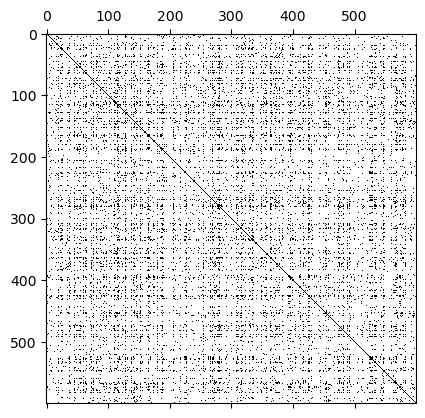

In [2]:
n, m = A.shape
print(n, m)
nz = np.count_nonzero(A)/(n*m)
perc_nz = nz*100
print("Percentuale degli elementi diversi da zero", perc_nz)
print("Condizionamento matrice ", np.linalg.cond(A))
plt.spy(A)

In [3]:
def s_d_p(A):
    if not np.allclose(A, A.T):
        print("Matrice non simmetrica")
        autovalori_pos = False
    else:
        print("Matrice simmetrica")
        autovalori = np.linalg.eigvals(A)
        autovalori_pos = np.all(autovalori > 0)
        
    return autovalori_pos

In [4]:
print(s_d_p(A))

Matrice simmetrica
True


In [5]:
def d_s_d(A):
    n = A.shape[0]
    for i in range(n):
        diagonale = abs(A[i, i])
        somma_fuori_diagonale = np.sum(abs(A[i, :])) - diagonale

        if diagonale <= somma_fuori_diagonale:
            return False
    return True

In [6]:
print(d_s_d(A))

False


In [7]:
def steepestdescent(A, b, x0, itmax, tol):
    # A = matrice del sistema
    # b = termine noto
    # x0 = punto iniziale
    # itmax = numero massimo di iterazioni
    # tol = tolleranza per il criterio di arresto

    n, m = A.shape  # dimensioni della matrice A
    if n != m:
        print("Matrice non quadrata")
        return [], []  # il metodo richiede una matrice quadrata

    # inizializzazione
    x = x0  # soluzione iniziale

    r = A@x-b #to do    
    p = r #to do  
    it = 0              # contatore iterazioni

    nb = np.linalg.norm(b)         
    errore = np.linalg.norm(r)/nb #to do                         # errore relativo iniziale

    vec_sol = []            # lista delle soluzioni iterate
    vec_sol.append(x.copy())

    vet_r = []              # lista degli errori
    vet_r.append(errore)

    # ciclo del metodo del gradiente
    while errore >= tol and it < itmax:
        it = it + 1  # incremento iterazioni

        Ap= A@p #to do  
        # calcolo del passo ottimo (minimizza lungo la direzione p)
        alpha = -(r.T@p) / (p.T@Ap) #to do

        # aggiornamento soluzione
        x= x + alpha*p #to do  

        # salva iterata
        vec_sol.append(x.copy())

        # aggiornamento residuo (più efficiente che ricalcolare A@x - b)
        r = r + alpha*Ap #to do  

        # aggiornamento errore
        errore = np.linalg.norm(r)/nb #to do
        vet_r.append(errore)

        # nuova direzione  
        p = -r #to do  

    # costruzione matrice delle iterate (ogni riga = una iterazione)
    iterates_array = np.array(vec_sol)

    # output
    return x, vet_r, iterates_array, it


Numero di iterazioni  121


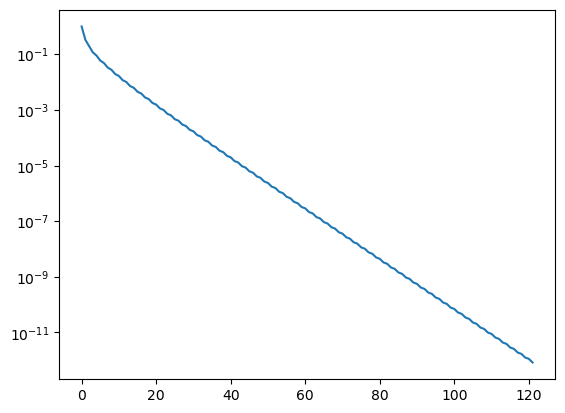

In [8]:
x0 = np.zeros_like(b)
toll = 1e-12
itmax = 2000
xG_1, vet_rG_1, it_a_G_1, it_G1_1 = steepestdescent(A, b, x0, itmax, toll)
#print(xG_1)
print("Numero di iterazioni ", it_G1_1)
plt.semilogy(range(it_G1_1 + 1), vet_rG_1)

In [9]:

def conjugate_gradient(A, b, x0, itmax,tol):
    # A = matrice del sistema
    # b = termine noto
    # x0 = punto iniziale
    # itmax = numero massimo di iterazioni
    # tol = tolleranza per il criterio di arresto

    n, m = A.shape  # dimensioni della matrice A
    if n != m:
        print("Matrice non quadrata")
        return [], []  # il metodo richiede una matrice quadrata

    # inizializzazione
    x = x0  # soluzione iniziale

    r = A@x-b #to do    
    p = r #to do  
    it = 0              # contatore iterazioni

    nb = np.linalg.norm(b)         
    errore = np.linalg.norm(r)/nb #to do                         # errore relativo iniziale

    vec_sol = []            # lista delle soluzioni iterate
    vec_sol.append(x.copy())

    vet_r = []              # lista degli errori
    vet_r.append(errore)

    # ciclo del metodo del gradiente
    while errore >= tol and it < itmax:
        it = it + 1  # incremento iterazioni

        Ap= A@p #to do  
        # calcolo del passo ottimo (minimizza lungo la direzione p)
        alpha = -(r.T@p) / (p.T@Ap) #to do

        # aggiornamento soluzione
        x= x + alpha*p #to do  

        # salva iterata
        vec_sol.append(x.copy())

        rtr_old=r.T@r
        
        # aggiornamento residuo (più efficiente che ricalcolare A@x - b)
        r = r + alpha*Ap #to do  

        gamma = (r.T@r)/rtr_old
        
        # aggiornamento errore
        errore = np.linalg.norm(r)/nb #to do
        vet_r.append(errore)

        # nuova direzione  
        p = -r+gamma*p #to do  

    # costruzione matrice delle iterate (ogni riga = una iterazione)
    iterates_array = np.array(vec_sol)

    # output
    return x, vet_r, iterates_array, it


Numero di iterazioni  56


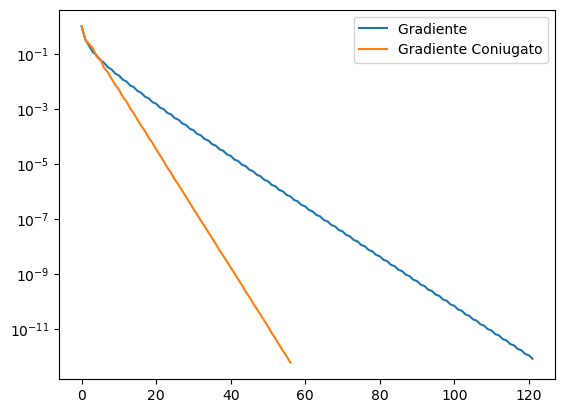

In [10]:
x0 = np.zeros_like(b)
toll = 1e-12
itmax = 2000
xCG_1, vet_rCG_1, it_a_CG_1, it_CG1_1 = conjugate_gradient(A, b, x0, itmax, toll)
#print(xCG_1)
print("Numero di iterazioni ", it_CG1_1)
plt.semilogy(range(it_G1_1 + 1), vet_rG_1, range(it_CG1_1 + 1), vet_rCG_1)
plt.legend(["Gradiente ","Gradiente Coniugato"])

600 600
Percentuale degli elementi diversi da zero 12.375
Condizionamento matrice  1000.0000000000581


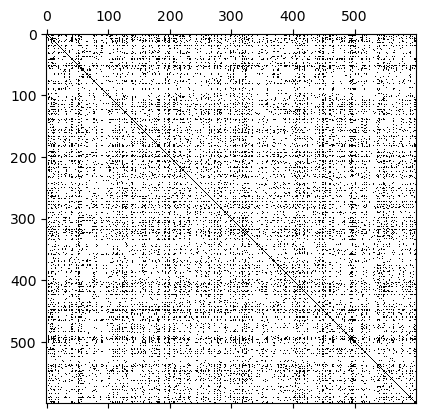

In [11]:
n, m = A1.shape
print(n, m)
nz = np.count_nonzero(A1)/(n*m)
perc_nz = nz*100
print("Percentuale degli elementi diversi da zero", perc_nz)
print("Condizionamento matrice ", np.linalg.cond(A1))
plt.spy(A1)

In [12]:
print(s_d_p(A1))
print(d_s_d(A1))

Matrice simmetrica
True
False


Numero di iterazioni  9717


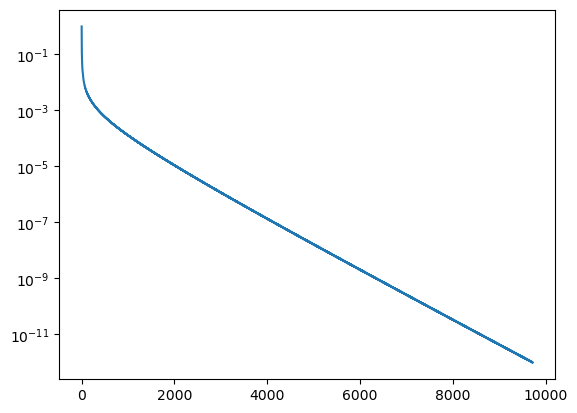

In [13]:
x0 = np.zeros_like(b1)
toll = 1e-12
itmax = 10000
xG_1, vet_rG_1, it_a_G_1, it_G1_1 = steepestdescent(A1, b1, x0, itmax, toll)
#print(xG_1)
print("Numero di iterazioni ", it_G1_1)
plt.semilogy(range(it_G1_1 + 1), vet_rG_1)

Numero di iterazioni  513


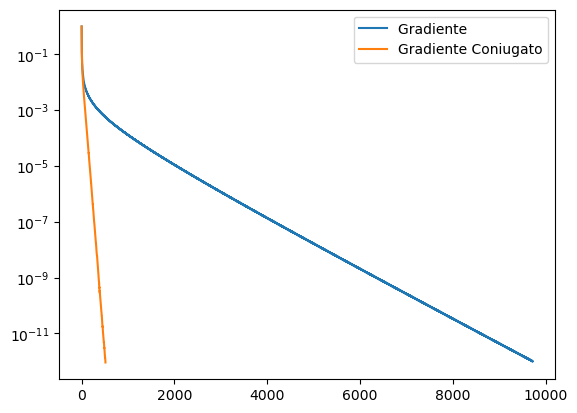

In [14]:
x0 = np.zeros_like(b1)
toll = 1e-12
itmax = 10000
xCG_1, vet_rCG_1, it_a_CG_1, it_CG1_1 = conjugate_gradient(A1, b1, x0, itmax, toll)
#print(xCG_1)
print("Numero di iterazioni ", it_CG1_1)
plt.semilogy(range(it_G1_1 + 1), vet_rG_1, range(it_CG1_1 + 1), vet_rCG_1)
plt.legend(["Gradiente ","Gradiente Coniugato"])

- Dato il sistema lineare Ax= b, con  matrice dei coefficienti
$$
A= \left[
\begin{array}{cccc}
3.0 &2.0 & 1.0 & -1.0\\
2.0 & 6.0 & 1.0 & 4.0\\
1.0 & 1.0 & 4.0 & 3.0\\
-1.0 & 4.0 & 3.0 & 7.0
\end{array}
\right ],$$
e termine noto b tale per cui la soluzione del sistema lineare sia il vettore formato da tutti 1,

- dire se  è possibile applicare il metodo di fattorizzazione di Cholesky richiamando il Teorema di Cholesky e verificare sperimentalmente le ipotesi di applicabilità. Risolvere il sistema lineare utilizzando la fattorizzazione di Cholesky se è possibile, altrimenti ricorrere ad un altro meodo di fattorizzazione, spiegandone le motivazioni.
 **[punti 2]**

In [16]:
A3 = np.array([[3.0, 2.0, 1.0, -1.0],[2.0, 6.0, 1.0, 4.0], [1.0, 1.0, 4.0, 3.0], [-1.0, 4.0, 3.0, 7.0]])
print("Matrice simmetrica definita positiva ", s_d_p(A3))

Matrice simmetrica
Matrice simmetrica definita positiva  False


## Esercizio 2

Si consideri il polinomio $$f(x)=x^4-13 \cdot x^3 + 62 \cdot x^2 - 128 \cdot x + 96.0 $$ 


Si visualizzi il grafico del polinomio in [1.7,4.6] 

In [19]:
import sympy as sym
from sympy.utilities.lambdify import lambdify

x = sym.symbols('x')
fs = x**4 - 13.0 * x**3 + 62 * x**2 - 128 * x + 96
fp_s = sym.diff(fs, x, 1)
f = lambdify(x, fs, np)
fp = lambdify(x, fp_s, np)

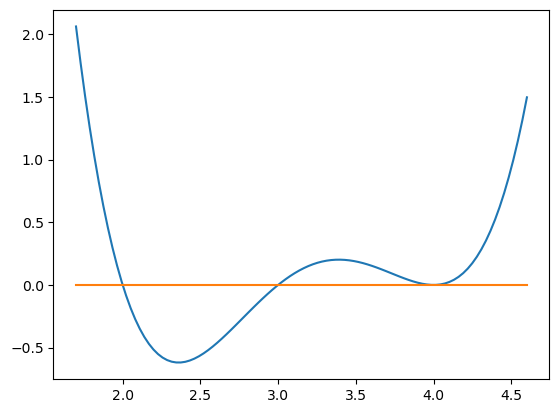

In [22]:
xx = np.linspace(1.7, 4.6, 100)
plt.plot(xx, f(xx), xx, np.zeros_like(xx))

- Si implementi il metodo di Newton per la determinazione degli zeri di un'equazione non lineare [**Punti 3**]

- Si implementi il metodo della regula falsi (falsa posizione)  per la determinazione degli zeri di un'equazione non lineare [**Punti 3**]

- Si utilizzi il metodo di Newton per individuare tutti gli zeri  del polinomio, (scegliendo opportunamente l'iterato iniziale per il calcolo di ciascuna di esse) e calcolare l'ordine del metodo per il calcolo di ciascuno zero. Dare la definizione teorica di ordine di convergenza e giustificare i risultati alla luce della teoria. [**Punti 4**]

In [29]:
def newton(fname,fpname,x0,tolx,tolf,nmax):
    
     # fpname è la lambda function contenente la derivata prima di fname
        v_xk=[]
        xk=x0
        
        it=0
        xk1=None
        errorex=1+tolx
        erroref=1+tolf
        while it < nmax and erroref >= tolf and errorex >= tolx: #to do
           
           fxk=fname(xk)
           fpxk=fpname(xk)
           if abs(fpxk) <= np.spacing(1): #to do 
             print("Newton: La derivata prima si annulla ")
             return None,None,None
        
           d= fxk/fpxk #to do
                    
           '''
           #xk1= ascissa del punto di intersezione tra  la retta che passa per il punto
           (xk,f(xk)) e ha pendenza uguale a quella della tangente nel punto  e l'asse x
           '''
           xk1= xk-d #to do
           
           fxk1=fname(xk1)
           
           if xk1!=0:
                errorex = abs(d) / abs(xk1) #to do
           else:
                errorex = abs(d) #to do 
           
           erroref=np.abs(fxk1)

           v_xk.append(xk1)
 
           xk=xk1
           it=it+1
          
        if it==nmax:
            print('Newton : raggiunto massimo numero di iterazioni \n')
            
        
        return xk1,it,np.array(v_xk)

In [30]:
def stima_ordine(xk,iterazioni):
     #Vedi dispensa allegata per la spiegazione

      k=iterazioni-4
      p=np.log(abs(xk[k+2]-xk[k+3])/abs(xk[k+1]-xk[k+2]))/np.log(abs(xk[k+1]-xk[k+2])/abs(xk[k]-xk[k+1]));
     
      ordine=p
      return ordine

In [31]:
x01 = 1.7
tolx = 1e-10
tolf = 1e-10
nmax = 100
x1, it1, v_xk1 = newton(f,fp,x01,tolx,tolf,nmax)
print("Pritmo zero stimato con newton ", x1, "Numero di iterazioni ", it1, "ordine del metodo ", stima_ordine(v_xk1, it1))

Pritmo zero stimato con newton  1.9999999999996614 Numero di iterazioni  5 ordine del metodo  2.004874118203259


In [32]:
x03 = 4.5
tolx = 1e-10
tolf = 1e-10
nmax = 100
x3, it3, v_xk3 = newton(f,fp,x03,tolx,tolf,nmax)
print("Pritmo zero stimato con newton ", x3, "Numero di iterazioni ", it3, "ordine del metodo ", stima_ordine(v_xk3, it3))

Pritmo zero stimato con newton  4.000006722044709 Numero di iterazioni  17 ordine del metodo  1.0009222466509995


In [33]:
def newton_modificato(fname,fpname,m,x0,tolx,tolf,nmax):
     #Il codice implementa il metodo di Newton modificato per radici multiple.
     #m è la molteplicità della radice
     # fpname è la lambda function contenente la derivata prima di fname
        # fpname è la lambda function contenente la derivata prima di fname
        v_xk=[]
        xk=x0
        
        it=0
        xk1=None
        errorex=1+tolx
        erroref=1+tolf
        while it < nmax and erroref >= tolf and errorex >= tolx: #to do
           
           fxk=fname(xk)
           fpxk=fpname(xk)
           if abs(fpxk) <= np.spacing(1): #to do 
             print("Newton: La derivata prima si annulla ")
             return None,None,None
        
           d= fxk/fpxk #to do
                    
           '''
           #xk1= ascissa del punto di intersezione tra  la retta che passa per il punto
           (xk,f(xk)) e ha pendenza uguale a quella della tangente nel punto  e l'asse x
           '''
           xk1= xk-m*d #to do
           
           fxk1=fname(xk1)
           
           if xk1!=0:
                errorex = abs(d) / abs(xk1) #to do
           else:
                errorex = abs(d) #to do 
           
           erroref=np.abs(fxk1)

           v_xk.append(xk1)
 
           xk=xk1
           it=it+1
          
        if it==nmax:
            print('Newton : raggiunto massimo numero di iterazioni \n')
            
        
        return xk1,it,np.array(v_xk)

In [36]:
molt = 2
x3, it3, v_xk3 = newton_modificato(f, fp, molt, x03, tolx, tolf, nmax)
print("Pritmo zero stimato con newton modificato ", x3, "Numero di iterazioni ", it3, "ordine del metodo ", stima_ordine(v_xk3, it3))

Pritmo zero stimato con newton modificato  3.9999999984299 Numero di iterazioni  4 ordine del metodo  1.9930845104512316


- Si consideri la funzione $g(x)=f(x)/((x-x_1^*)(x-x_2^*))$ dove $x_1^*$ ed $x_2^*$ sono  gli zeri del polinomio di ascissa più piccola e più grande, rispettivamente, tra quelli calcolati al punto precedente. 
Visualizzare i grafici di g(x) e f(x) e dire se i due polinomi hanno degli zeri in comune. 
Calcolare con il metodo di Newton gli zeri di $g(x)$ [**Punti 1**]

- Si applichi il metodo della regula falsi alle funzioni $f(x)$ e $g(x)$ nell'intervallo  [1.7,4.6] e si fornisca una spiegazione teorica dei risultati ottenuti. Si indichi  un intervallo di studio opportuno affinchè con il metodo di falsa posizione sia possibile calcolare la radice con ascissa maggiore della funzione g(x) e verificare sperimentalmente che porta a soluzione  [**Punti 2**]

# Domande IA

**1.**  Quali di queste affermazioni sono vere: 

    (a) La procedura di “annotazione” consiste nell’ottenere, per un certo dato di input, l’etichetta predetta da un dato modello 

    (b)  I dati annotati sono necessari in un contesto di learning supervisionato 

    (c) Non tutti gli algoritmi di Machine Learning necessitano di dati annotati 

    (d) In un problema di apprendimento automatico il cui scopo è la predizione dell’altezza di una persona, l’età è un’etichetta utile 

**2.** Quali di queste affermazioni sono vere: 

    (a)  Non esistono reti che prevedono connessioni all'indietro, ma esistono reti che prevedono biforcazioni 

    (b) Al fine di apprendere relazioni complesse, le funzioni di attivazione devono essere sia derivabili che non-lineari 

    (c) L’obiettivo del processo di apprendimento dei pesi di una rete neurale è quello di minimizzare la funzione obiettivo, ovvero a minimizzare la funzione di costo. 

    (d) Il Multilayer Perceptron (MLP) prevede la presenza di layer “hidden” 


**3.**  Quali di queste affermazioni sono vere: 

    (a)  In una rete Multilayer Perceptron l’immagine viene appiattita e non si tiene conto della sua struttura bidimensionale 

    (b)  In un layer di convoluzione, la convoluzione è applicata a un’immagine con un meccanismo di sliding window 

    (c)  In una rete Convolutional Neural Network (CNN) è ammessa la presenza esclusivamente di layer di convoluzione (sia 2D che 3D), layer di pooling ed eventualmente di normalizzazione e dropout 

    (d)  Se un’immagine di input ha 3 canali e viene passata in input a un layer di convoluzione che prevede 10 kernel, l’output di tale layer sarà un tensore di 30 canali 3- Quale delle seguenti affermazioni è vera riguardo ai layer convoluzionali in una rete CNN?


**4.**  Quali di queste affermazioni sono vere: 

Il dataset di validazione 

    (a)  Può essere usato per tarare gli iperparametri del modello 

    (b)  Può essere usato per verificare una discrepanza rispetto all'accuratezza ottenuta sul training set 

    (c)  La sua dimensione dovrebbe essere simile a quella del training set 

    (d)  Il suo contenuto deve essere completamente disgiunto da quello del test set 

**5.**  Quale delle seguenti affermazioni è la definizione CORRETTA di learning rate nel training di una rete neurale?

    (a) Il numero di volte in cui l'intero set di dati viene utilizzato durante il training.

    (b) Un parametro che controlla la velocità con cui i pesi della rete vengono aggiornati durante il training.

    (c) Il numero di neuroni presenti nello strato di output della rete.

    (d) La funzione di attivazione utilizzata dai neuroni della rete 

# Domande aperte

**6. Si descrivano le fasi di forward-propagation e back-propagation nel contesto dell'addestramento di una rete neurale**.   [punti 1.5]

**7. Descrivere il Gradient Descent con Momentum, spiegando il ruolo del termine di velocità, il significato del
parametro di momentum e in che modo questo metodo permette di ridurre le oscillazioni e accelerare la
convergenza rispetto al Gradient Descent classico**[punti 3]